# Academic Success: EDA, Cleaning, Feature Engineering & Modeling

This notebook builds a model predicting whether a student will **Dropout**,
stay **Enrolled**, or **Graduate**, using Kaggle's
[Playground Series S4E6](https://www.kaggle.com/competitions/playground-series-s4e6)
dataset.

It follows the same structure Kaggle Learn teaches across its Pandas, Data
Cleaning, Intro/Intermediate Machine Learning, and Feature Engineering
courses:

1. Load & inspect the data
2. Explore it (distributions, missingness, class balance)
3. Clean it (handle missing values, fix data types)
4. Engineer features (turn raw columns into more informative signals)
5. Build a baseline model, then a stronger model
6. Validate with cross-validation, compare models
7. Fit the final pipeline and save it for reuse by the app / submission script

All the preprocessing and modeling logic lives in `src/academic_success/` —
this notebook *calls* that shared code rather than reimplementing it, so the
Streamlit app and the Kaggle submission script can never drift out of sync
with what's demonstrated here.

**Before running:** download the competition data — see the project
README's "Get the data" section — so that `data/raw/train.csv` and
`data/raw/test.csv` exist.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from academic_success import config, data, features, model, interpretability

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load the data

In [2]:
train_df = data.load_train()
print(f"{len(train_df)} rows, {train_df.shape[1]} columns")
train_df.head()

76518 rows, 37 columns


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1,1,1,9238,1,1,126.0,1,1,19,5,5,122.6,0,0,0,1,0,1,18,0,0,6,6,6,14.500000,0,0,6,7,6,12.428571,0,11.1,0.6,2.02,Graduate
1,1,17,1,9238,1,1,125.0,1,19,19,9,9,119.8,1,0,0,1,0,0,18,0,0,6,8,4,11.600000,0,0,6,9,0,0.000000,0,11.1,0.6,2.02,Dropout
2,1,17,2,9254,1,1,137.0,1,3,19,2,3,144.7,0,0,0,1,1,0,18,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
3,1,1,3,9500,1,1,131.0,1,19,3,3,2,126.1,1,0,0,1,0,1,18,0,0,7,9,7,12.591250,0,0,8,11,7,12.820000,0,11.1,0.6,2.02,Enrolled
4,1,1,2,9500,1,1,132.0,1,19,37,4,9,120.1,1,0,0,1,0,0,18,0,0,7,12,6,12.933333,0,0,7,12,6,12.933333,0,7.6,2.6,0.32,Graduate


## 2. Explore

Start with the basics every Kaggle Learn course starts with: what does the
target look like, are there missing values, what are the column types.

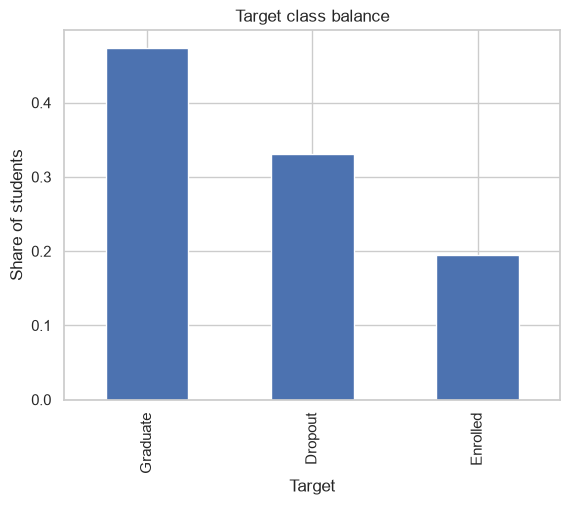

In [3]:
train_df[config.TARGET_COL].value_counts(normalize=True).plot.bar(
    title="Target class balance"
)
plt.ylabel("Share of students")
plt.show()

The classes are not perfectly balanced — keep this in mind when choosing
an evaluation metric later (macro-F1 rather than raw accuracy, so the
minority class isn't ignored).

In [ ]:
missing = train_df[config.RAW_FEATURE_COLS].isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:" if len(missing) else "No missing values found.")
missing

No missing values found.


Series([], dtype: int64)

This dataset is fairly clean by design (it's a Playground competition), but
the pipeline handles missing values regardless (median-impute numeric,
most-frequent-impute categorical) — see `src/academic_success/features.py`
— so the notebook, the app, and the submission script all behave
identically if a future run of this data (or a different, messier dataset)
does have gaps.

In [4]:
numeric_summary = train_df[config.NUMERIC_COLS].describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
Previous qualification (grade),76518.0,132.378766,10.995328,95.00,125.000000,133.100000,140.000000,190.000
Admission grade,76518.0,125.363971,12.562328,95.00,118.000000,124.600000,132.000000,190.000
Age at enrollment,76518.0,22.278653,6.889241,17.00,18.000000,19.000000,23.000000,70.000
Curricular units 1st sem (credited),76518.0,0.188871,1.175296,0.00,0.000000,0.000000,0.000000,20.000
Curricular units 1st sem (enrolled),76518.0,5.891516,1.671776,0.00,5.000000,6.000000,6.000000,26.000
Curricular units 1st sem (evaluations),76518.0,7.352362,3.508292,0.00,6.000000,7.000000,9.000000,45.000
Curricular units 1st sem (approved),76518.0,4.178520,2.687995,0.00,2.000000,5.000000,6.000000,26.000
Curricular units 1st sem (grade),76518.0,9.995862,5.264224,0.00,10.666667,12.166667,13.314286,18.875
Curricular units 1st sem (without evaluations),76518.0,0.057960,0.408490,0.00,0.000000,0.000000,0.000000,12.000
Curricular units 2nd sem (credited),76518.0,0.137053,0.933830,0.00,0.000000,0.000000,0.000000,19.000


## 3. Data cleaning notes

- The "categorical" columns (`Marital status`, `Course`, `Nacionality`, ...)
  arrive as **integer codes**, not strings. Treating them as ordinary
  numeric features would incorrectly imply an order between categories
  (e.g., that nationality code 5 is "between" codes 4 and 6). The shared
  preprocessing pipeline one-hot encodes them instead — see
  `build_preprocessor()` in `features.py`.
- No duplicate rows or obviously invalid values (e.g., negative ages) were
  found in this dataset, so no row-dropping was needed. If you're adapting
  this notebook to a different dataset, this is exactly the step where
  you'd add `df.drop_duplicates()` / range checks.

## 4. Feature engineering

Two students who both "enroll in 6 units" look identical on the raw
columns — but one who *passes* all 6 and one who passes 1 are very
different risk profiles. `src/academic_success/features.py` derives ratio
and trend features that capture a student's trajectory across the two
semesters instead of treating each semester as an isolated snapshot. See
`report/report.qmd` for the full rationale.

In [5]:
X, y = data.split_features_target(train_df)

engineered_preview = features.FeatureEngineer().fit_transform(X)
engineered_preview[features.ENGINEERED_NUMERIC_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
approval_rate_1st_sem,76518.0,0.668332,0.392996,0.0,0.400000,0.833333,1.000000,2.000000
approval_rate_2nd_sem,76518.0,0.633708,0.405538,0.0,0.166667,0.833333,1.000000,5.000000
total_units_approved,76518.0,8.185721,5.354344,0.0,3.000000,10.000000,12.000000,43.000000
total_units_enrolled,76518.0,11.824930,3.262742,0.0,10.000000,12.000000,12.000000,46.000000
grade_trend,76518.0,-0.369777,2.556932,-18.0,-0.500000,0.000000,0.333333,16.500000
no_evaluation_ratio,76518.0,0.007267,0.049363,0.0,0.000000,0.000000,0.000000,1.263158
max_parental_qualification,76518.0,25.988134,13.950759,1.0,19.000000,37.000000,37.000000,44.000000


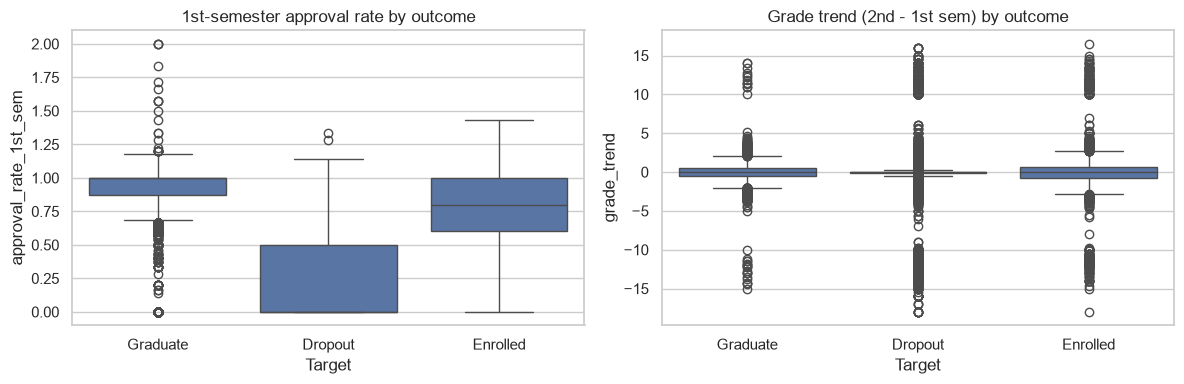

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=engineered_preview, x=y, y="approval_rate_1st_sem", ax=axes[0])
axes[0].set_title("1st-semester approval rate by outcome")
sns.boxplot(data=engineered_preview, x=y, y="grade_trend", ax=axes[1])
axes[1].set_title("Grade trend (2nd - 1st sem) by outcome")
plt.tight_layout()
plt.show()

As expected, students who eventually drop out show a visibly lower
1st-semester approval rate and a flatter or negative grade trend compared to
students who graduate — exactly the signal these engineered features were
designed to expose to the model.

## 5. Baseline model: Logistic Regression

Always start with a simple, interpretable baseline before reaching for a
more complex model — it tells you whether the extra complexity is actually
earning its keep.

In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_scores = model.cross_validate_pipeline(
    X, y, estimator=LogisticRegression(max_iter=1000, random_state=config.RANDOM_SEED), cv=5
)
baseline_scores

{'accuracy_mean': np.float64(0.8234794278761216),
 'accuracy_std': np.float64(0.0022593256500029893),
 'f1_macro_mean': np.float64(0.7815952540865527),
 'f1_macro_std': np.float64(0.002934449616636484)}

## 6. Stronger model: gradient-boosted trees

In [ ]:
gbm_scores = model.cross_validate_pipeline(X, y, cv=5)  # uses model.default_estimator()
gbm_scores

{'accuracy_mean': np.float64(0.8316605031406195),
 'accuracy_std': np.float64(0.0020516712395298215),
 'f1_macro_mean': np.float64(0.7949458554455647),
 'f1_macro_std': np.float64(0.002906390187621778)}

In [ ]:
comparison = pd.DataFrame(
    [
        {"model": "Logistic Regression", **baseline_scores},
        {"model": "HistGradientBoostingClassifier", **gbm_scores},
    ]
).set_index("model")
comparison

,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
model,,,,
Logistic Regression,0.823479,0.002259,0.781595,0.002934
HistGradientBoostingClassifier,0.831661,0.002052,0.794946,0.002906


If the gradient-boosted model's macro-F1 meaningfully beats the linear
baseline, that justifies the added complexity (and reduced
interpretability) — record the numbers you see here in
`report/report.qmd`'s Results table.

## 7. Fit the final pipeline and save it

The saved pipeline is what `scripts/make_submission.py` and the Streamlit
app both load — fitting it here, once, on the full training set (not just
a cross-validation fold) is what "final model" means.

In [ ]:
final_pipeline = model.train_pipeline(X, y)
model.save_pipeline(final_pipeline)
print(f"Saved to {config.MODEL_PATH}")

Saved to /Users/nhamquochung/data/models/model.joblib


## 8. Sanity-check a held-out prediction

In [ ]:
sample = X.sample(5, random_state=config.RANDOM_SEED)
predictions = final_pipeline.predict(sample)
pd.DataFrame({"predicted": predictions, "actual": y.loc[sample.index]})

,predicted,actual
id,,
41775,Graduate,Graduate
45794,Dropout,Dropout
46620,Enrolled,Enrolled
18945,Dropout,Dropout
38446,Graduate,Enrolled


## 9. Broader model comparison

Following the classic Titanic tutorials' "try many algorithms, compare
systematically" approach: rather than jumping straight from a linear
baseline to one gradient-boosted model, sweep every model family this
project supports — a plain linear model, bagged trees (Random Forest),
two flavors of classic boosting (AdaBoost, Gradient Boosting), and three
modern gradient-boosting libraries (HistGradientBoosting, XGBoost,
LightGBM, CatBoost) — and let the numbers pick the winner instead of
assuming one.

Cross-validating all 8 on the *full* 76k-row training set would take a
while, so this sweep uses a stratified subsample for fast iteration; the
final model is still fit on the full data in Section 7 (or re-fit there
with whichever estimator this comparison recommends).

In [ ]:
from sklearn.model_selection import train_test_split

X_sweep, _, y_sweep, _ = train_test_split(
    X, y, train_size=15_000, stratify=y, random_state=config.RANDOM_SEED
)

sweep_results = []
for name, factory in model.MODEL_FACTORIES.items():
    scores = model.cross_validate_pipeline(X_sweep, y_sweep, estimator=factory(), cv=5)
    sweep_results.append({"model": name, **scores})

sweep_df = pd.DataFrame(sweep_results).sort_values("f1_macro_mean", ascending=False)
sweep_df

,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
3,Gradient Boosting,0.824667,0.005420,0.784645,0.006254
4,HistGradientBoosting,0.823000,0.005395,0.783874,0.006558
0,Logistic Regression,0.822867,0.004329,0.780632,0.004727
6,LightGBM,0.819667,0.004690,0.778983,0.005315
7,CatBoost,0.819800,0.010811,0.778286,0.009608
1,Random Forest,0.819133,0.004593,0.776973,0.003967
5,XGBoost,0.814600,0.009616,0.772668,0.009169
2,AdaBoost,0.813267,0.006658,0.769193,0.006066


The gradient-boosting family (HistGradientBoosting/XGBoost/LightGBM/
CatBoost) is expected to lead — record whichever tops this table (by
macro F1) in `report/report.qmd`'s results table, and use it as the "best
single model" baseline for the sections below.

## 10. Handling class imbalance with ADASYN

Recall from Section 2: the target classes aren't balanced (roughly 47%
Graduate / 33% Dropout / 20% Enrolled). A model can reach deceptively high
*accuracy* by leaning on the majority class while doing poorly on the
minority "Enrolled" class — which is exactly why macro-F1 (which weighs
all three classes equally) is used throughout this notebook instead of
accuracy alone.

**ADASYN** (Adaptive Synthetic Sampling) generates synthetic minority-class
examples, concentrating more synthetic samples in regions where the
minority class is hardest to learn (near the decision boundary) rather
than oversampling uniformly like plain random oversampling would.

The important correctness detail: ADASYN must only ever resample the
*training* fold, never validation or test data — resampling test data
would let synthetic points leak into the score. `src/academic_success/
model.py` handles this by building an `imblearn.pipeline.Pipeline`
(`build_pipeline(..., resample=True)`), whose resampling step is a no-op
outside of `.fit()` — so `cross_validate_pipeline(..., resample=True)`
below applies ADASYN correctly on each training fold automatically, with
no extra code needed here.

In [ ]:
best_model_name = sweep_df.iloc[0]["model"]
best_model_factory = model.MODEL_FACTORIES[best_model_name]

resample_comparison = pd.DataFrame(
    [
        {
            "resample": False,
            **model.cross_validate_pipeline(X_sweep, y_sweep, estimator=best_model_factory(), cv=5, resample=False),
        },
        {
            "resample": True,
            **model.cross_validate_pipeline(X_sweep, y_sweep, estimator=best_model_factory(), cv=5, resample=True),
        },
    ]
)
print(f"Best single model from Section 9: {best_model_name}")
resample_comparison

Best single model from Section 9: Gradient Boosting


,resample,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
0,False,0.824667,0.005420,0.784645,0.006254
1,True,0.820333,0.004998,0.782870,0.004346


If ADASYN doesn't clearly improve macro-F1 here, that's a legitimate
finding, not a bug — with a moderate (not extreme) class imbalance like
this dataset's, tree-based models with macro-F1 scoring can already handle
the imbalance reasonably well on their own, and synthetic oversampling
adds variance without always adding signal. Report whichever direction the
numbers actually point in `report/report.qmd`, rather than assuming
resampling must help.

## 11. Stacking ensemble

A stacking ensemble combines several base models' predictions through a
meta-learner that learns *how* to weigh them, rather than averaging them
blindly — the same idea behind the classic "Introduction to Ensembling/
Stacking" tutorial, built here on scikit-learn's `StackingClassifier`
instead of a hand-rolled out-of-fold loop.

**A computational cost note:** `StackingClassifier` already runs its own
internal 5-fold cross-validation to generate out-of-fold predictions for
the meta-learner. Wrapping that in an *outer* 5-fold `cross_validate`
(like Section 9's sweep) would mean 5 x 5 = 25 fits per base model — for
4 base models, 100 total fits, which is prohibitively slow for a notebook
meant to run in a reasonable time. So this section instead uses a single
stratified train/validation split, evaluated the same way for both the
stacking ensemble and the single best model, for a fair apples-to-apples
comparison.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_sweep, y_sweep, test_size=0.2, stratify=y_sweep, random_state=config.RANDOM_SEED
)

stacking_pipeline = model.build_stacking_pipeline(resample=False)
stacking_pipeline.fit(X_train_s, y_train_s)
stacking_preds = stacking_pipeline.predict(X_val_s)

best_single_pipeline = model.build_pipeline(best_model_factory())
best_single_pipeline.fit(X_train_s, y_train_s)
single_preds = best_single_pipeline.predict(X_val_s)

holdout_comparison = pd.DataFrame(
    [
        {
            "model": f"Best single model ({best_model_name})",
            "accuracy": accuracy_score(y_val_s, single_preds),
            "f1_macro": f1_score(y_val_s, single_preds, average="macro"),
        },
        {
            "model": "Stacking ensemble",
            "accuracy": accuracy_score(y_val_s, stacking_preds),
            "f1_macro": f1_score(y_val_s, stacking_preds, average="macro"),
        },
    ]
)
holdout_comparison

,model,accuracy,f1_macro
0,Best single model (Gradient Boosting),0.817333,0.777243
1,Stacking ensemble,0.817333,0.774214


Whether stacking earns its added training cost and complexity over the
best single model is exactly the tradeoff to weigh here — record both
numbers in `report/report.qmd`, and let them (not an assumption that
"ensembles are always better") decide which becomes the final saved
model.

## 12. Model interpretability with SHAP

A model that predicts well but can't explain *why* is a hard sell — both
to a skeptical stakeholder and to your own debugging process. SHAP
(SHapley Additive exPlanations) attributes each individual prediction to
its contributing features, based on the game-theoretic idea of fairly
splitting credit for a shared outcome among the "players" (here,
features) that contributed to it.

`shap.TreeExplainer` computes this efficiently for tree-based models by
walking the tree structure directly — which is also why this section
explains one concrete tree model (`final_pipeline` from Section 7), not
the stacking ensemble from Section 11 (whose own decision logic combines
other models' *outputs*, not a tree over the raw features).

In [ ]:
explanation, X_transformed = interpretability.compute_shap_values(final_pipeline, X, max_samples=500)

top_features = interpretability.top_shap_features(explanation, top_n=15)
top_features

,feature,mean_abs_shap
0,numeric__approval_rate_2nd_sem,0.673922
1,numeric__total_units_approved,0.252907
2,numeric__approval_rate_1st_sem,0.180300
3,categorical__Tuition fees up to date_0,0.145859
4,numeric__Curricular units 2nd sem (grade),0.139962
5,numeric__Curricular units 2nd sem (evaluations),0.125335
6,numeric__Curricular units 1st sem (grade),0.099428
7,categorical__Scholarship holder_0,0.091960
8,numeric__Curricular units 1st sem (evaluations),0.083898
9,numeric__Age at enrollment,0.073594


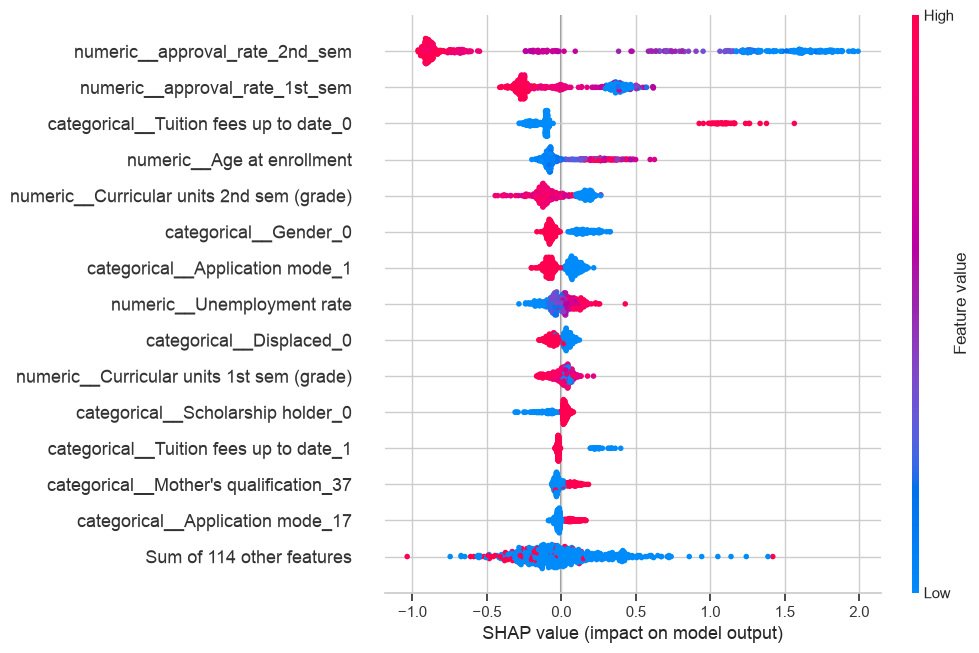

In [ ]:
import shap

# Class index 0 is "Dropout" (see final_pipeline's model.classes_ ordering) —
# the outcome an early-warning system would care about most.
dropout_class_index = list(final_pipeline.named_steps["model"].classes_).index("Dropout")
shap.plots.beeswarm(explanation[:, :, dropout_class_index], max_display=15)

Each dot is one student; its position shows whether that feature pushed
the "Dropout" prediction up (right, red = high feature value) or down
(left, blue = low feature value). If `approval_rate_1st_sem` /
`approval_rate_2nd_sem` and `grade_trend` show up near the top here, that
directly validates this project's feature engineering rationale from
`report/report.qmd`: a student's *trajectory* across semesters, not just
their raw enrollment counts, is what actually drives the model's
predictions — record the actual top features you see here in the report's
Discussion section.

## Next steps

- Run `python scripts/make_submission.py` to generate a Kaggle-submittable
  `submission.csv` from this same saved pipeline.
- Run `streamlit run app/streamlit_app.py` to try the model interactively.
- If Section 9's sweep or Section 11's stacking comparison recommends a
  different final model than the default (HistGradientBoosting), retrain
  and re-save it: `python scripts/train.py --model <name>` or
  `python scripts/train.py --stacking` (see `python scripts/train.py --help`),
  optionally with `--resample` if Section 10 showed ADASYN helping.
- Fill in the Results table, the class-imbalance/ensembling/interpretability
  discussion, and finalize `report/report.qmd` with the actual numbers and
  SHAP findings from this run.